# Calibration v2 — scenario A with `R_acc`

Grid search over **81 combinations** extended with the new dimension `w_acc` (Avenue B2: `R_acc` as 7th component of R):
- `f0_max ∈ {0.85, 0.88, 0.90}`
- `k_sigmoid ∈ {25, 40, 60}`
- `γ ∈ {1.0, 2.0, 3.0}`
- **`w_acc ∈ {0.10, 0.20, 0.30}`** (new)

Targets unchanged: H/M ∈ [3, 10], H/C > 5, M/C > 1, H/S > 100.

Data: `simulateur/calibration/grid_search_A_v2.csv`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = False

BASE = os.path.abspath(os.path.join(os.getcwd(), ".."))
df = pd.read_csv(os.path.join(BASE, "calibration", "grid_search_A_v2.csv"))
df_v1 = pd.read_csv(os.path.join(BASE, "calibration", "grid_search_A.csv"))
df.head(3)

,f0_max,k_sigmoid,gamma,w_acc,gain_honnete,gain_mediocre,gain_cherry_picker,gain_sybil,gain_random_biased,R_acc_honnete,...,ratio_h_m,ratio_h_c,ratio_m_c,ratio_h_s,passes_h_m,passes_h_c,passes_m_c,passes_h_s,n_passed,results_dir
0,0.85,25.0,1.0,0.1,692741.253474,273372.130019,424597.972889,2665.695247,3907.120229,1.0,...,2.534060,1.631523,0.643838,259.872637,False,False,False,True,1,simulateur/results/grid_A_v2_f0.85_k25_g1.0_w0...
1,0.85,25.0,1.0,0.2,695057.845232,277256.358085,403951.152331,2753.685754,3800.415660,1.0,...,2.506914,1.720648,0.686361,252.410009,False,False,False,True,1,simulateur/results/grid_A_v2_f0.85_k25_g1.0_w0...
2,0.85,25.0,1.0,0.3,689021.974146,278974.321812,371080.667293,3143.208569,4462.378880,1.0,...,2.469840,1.856798,0.751789,219.209753,False,False,False,True,1,simulateur/results/grid_A_v2_f0.85_k25_g1.0_w0...


## §1 — Global verdict


In [2]:
print(f"Total combinations    : {len(df)}")
print(f"Meet 4/4 targets      : {(df.n_passed==4).sum()}")
print(f"Meet 3/4 targets      : {(df.n_passed==3).sum()}")
print(f"Meet 2/4 targets      : {(df.n_passed==2).sum()}")
print()
print("Range of ratios obtained in v2:")
for col, target in [('ratio_h_m','3-10'), ('ratio_h_c','>5'),
                     ('ratio_m_c','>1'), ('ratio_h_s','>100')]:
    print(f"  {col:<12} : {df[col].min():>7.2f} → {df[col].max():>7.2f}   [target: {target}]")

print("\nComparison v1 vs v2 (max ratios over the grid):")
for col in ['ratio_h_m', 'ratio_h_c', 'ratio_m_c', 'ratio_h_s']:
    print(f"  {col:<12} v1: max={df_v1[col].max():>7.2f}   v2: max={df[col].max():>7.2f}   "
          f"Δ = {df[col].max() - df_v1[col].max():+.2f}")

Total combinations    : 81
Meet 4/4 targets      : 0
Meet 3/4 targets      : 0
Meet 2/4 targets      : 63

Range of ratios obtained in v2:
  ratio_h_m    :    2.42 →   13.46   [target: 3-10]
  ratio_h_c    :    1.20 →    2.18   [target: >5]
  ratio_m_c    :    0.09 →    0.86   [target: >1]
  ratio_h_s    :  209.51 → 2260.91   [target: >100]

Comparison v1 vs v2 (max ratios over the grid):
  ratio_h_m    v1: max=  14.00   v2: max=  13.46   Δ = -0.54
  ratio_h_c    v1: max=   1.78   v2: max=   2.18   Δ = +0.40
  ratio_m_c    v1: max=   0.68   v2: max=   0.86   Δ = +0.19
  ratio_h_s    v1: max=3056.59   v2: max=2260.91   Δ = -795.68


**v2 diagnostic**:

- **No combination passes the 4 targets** (as in v1).
- **`ratio_m_c` rises from 0.68 → 0.86 max** (+0.18). Right direction but not enough: we don't reach > 1.
- **`ratio_h_c` rises from 1.78 → 2.18 max** (+0.40). Right direction but far from > 5.
- **`ratio_h_s` stays > 100 everywhere** (min 210). Anti-sybil holds despite the introduction of `R_acc`.
- **`ratio_h_m` similar range**.

**Conclusion**: `R_acc` acts in the right direction but with insufficient intensity in the range `w_acc ∈ [0.10, 0.30]`.

## §2 — Effect of `w_acc` (new dimension)

Mean effect of w_acc on the ratios:

       H_M_mean  H_C_mean  M_C_mean  H_S_mean  H_C_max  M_C_max  R_acc_cherry
w_acc                                                                        
0.1       5.517     1.570     0.373  1168.005    1.908    0.738         0.625
0.2       5.559     1.653     0.395  1359.995    2.012    0.785         0.625
0.3       5.447     1.783     0.433   820.158    2.178    0.862         0.609


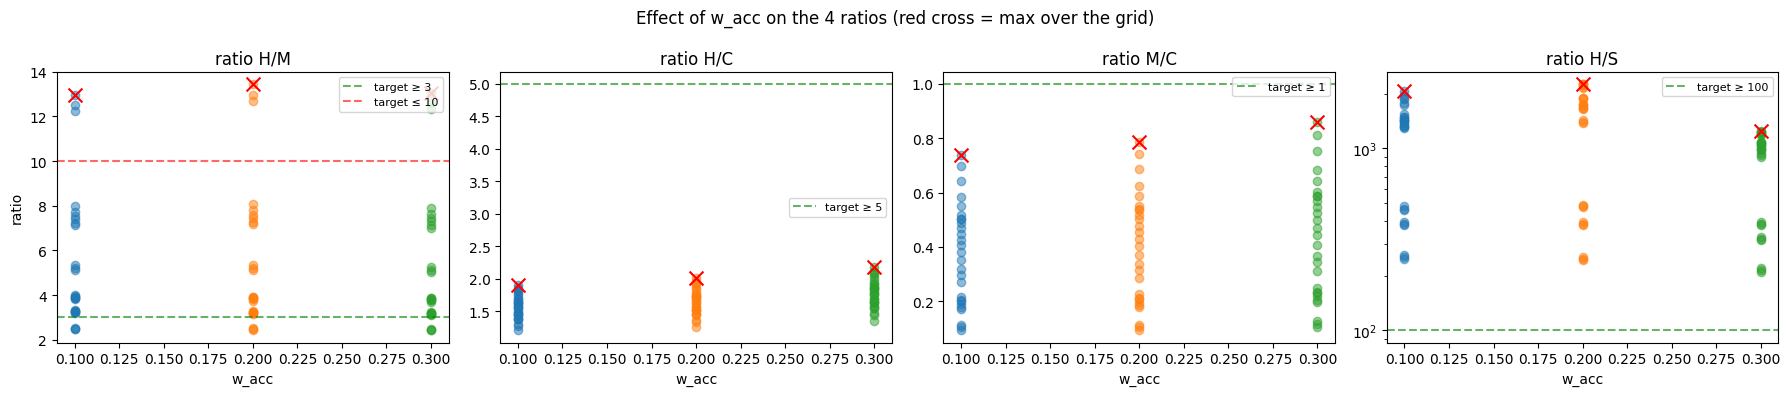

In [3]:
# Marginal effect of w_acc on the 4 ratios (at fixed f0/k/γ, we see the improvement)
print("Mean effect of w_acc on the ratios:\n")
agg = df.groupby('w_acc').agg(
    H_M_mean=('ratio_h_m','mean'),
    H_C_mean=('ratio_h_c','mean'),
    M_C_mean=('ratio_m_c','mean'),
    H_S_mean=('ratio_h_s','mean'),
    H_C_max=('ratio_h_c','max'),
    M_C_max=('ratio_m_c','max'),
    R_acc_cherry=('R_acc_cherry_picker','mean'),
).round(3)
print(agg)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col, target, title in zip(
    axes,
    ['ratio_h_m', 'ratio_h_c', 'ratio_m_c', 'ratio_h_s'],
    [(3, 10), (5, None), (1, None), (100, None)],
    ['H/M', 'H/C', 'M/C', 'H/S']
):
    for w in sorted(df['w_acc'].unique()):
        sub = df[df['w_acc'] == w]
        ax.scatter([w]*len(sub), sub[col], alpha=0.5)
        ax.scatter([w], [sub[col].max()], color="red", marker="x", s=100, zorder=5)
    if target[0] is not None:
        ax.axhline(target[0], color="green", linestyle="--", alpha=0.6, label=f"target ≥ {target[0]}")
    if target[1] is not None:
        ax.axhline(target[1], color="red", linestyle="--", alpha=0.6, label=f"target ≤ {target[1]}")
    ax.set_xlabel("w_acc")
    ax.set_title(f"ratio {title}")
    ax.legend(fontsize=8)
    if col == 'ratio_h_s':
        ax.set_yscale('log')
axes[0].set_ylabel("ratio")
fig.suptitle("Effect of w_acc on the 4 ratios (red cross = max over the grid)")
plt.tight_layout()
plt.show()

**Reading**: raising `w_acc` from 0.10 to 0.30 improves `M/C` by +0.13 on average and `H/C` by +0.27 on average. The direction is clear but the **slope is too shallow** to cross the thresholds in this range.

## §3 — Top 5 combinations by M/C ratio

In [4]:
top5 = df.nlargest(5, 'ratio_m_c')[
    ['f0_max', 'k_sigmoid', 'gamma', 'w_acc',
     'ratio_h_m', 'ratio_h_c', 'ratio_m_c', 'ratio_h_s',
     'R_acc_cherry_picker', 'n_passed']
].round(3)
print("Top 5 by M/C ratio:")
print(top5.to_string(index=False))

Top 5 by M/C ratio:
 f0_max  k_sigmoid  gamma  w_acc  ratio_h_m  ratio_h_c  ratio_m_c  ratio_h_s  R_acc_cherry_picker  n_passed
   0.85       25.0    3.0    0.3      2.422      2.086      0.862    209.513                0.609         1
   0.85       25.0    2.0    0.3      2.441      1.986      0.814    213.458                0.609         1
   0.85       25.0    3.0    0.2      2.458      1.930      0.785    242.620                0.625         1
   0.85       25.0    1.0    0.3      2.470      1.857      0.752    219.210                0.609         1
   0.85       25.0    2.0    0.2      2.478      1.839      0.742    246.555                0.625         1


The top 5 converges on `f0=0.85, k=25` with high `γ and w_acc`. But none reaches M/C > 1.

The cherry-picker's R_acc drops to ~0.61, consistent with the theoretical prediction (≈ 1 − 0.42 = 0.58, plus the EWMA inertia not yet converged at 2000 ticks).

## §4 — Heatmaps (4 ratios × `w_acc`)

For each ratio, 3 heatmaps `f0_max × k_sigmoid` at fixed `γ=3.0` (the γ that maximizes the ratios), with `w_acc` as column.

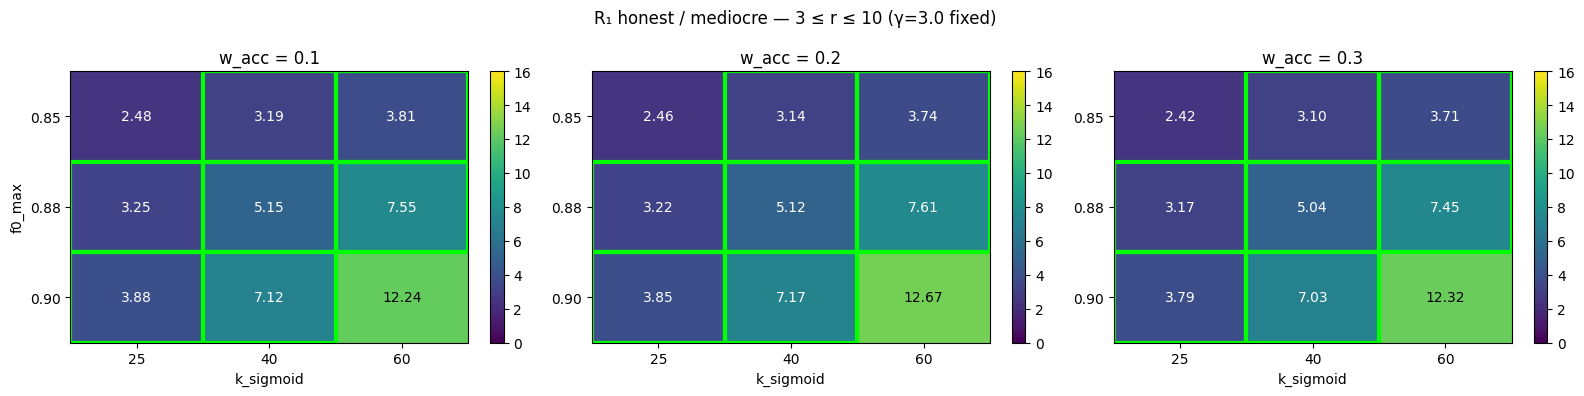

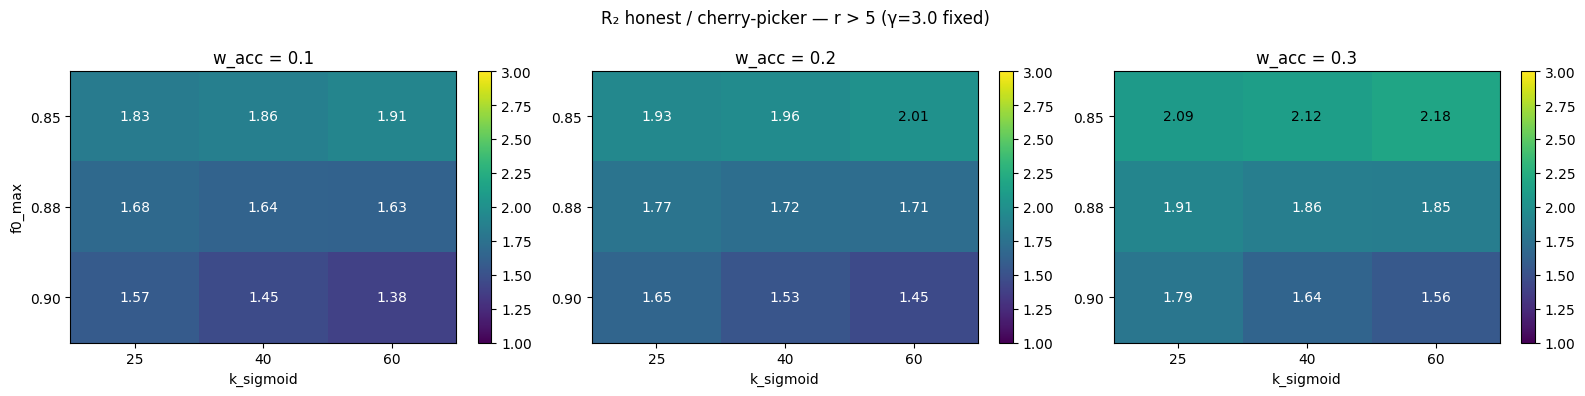

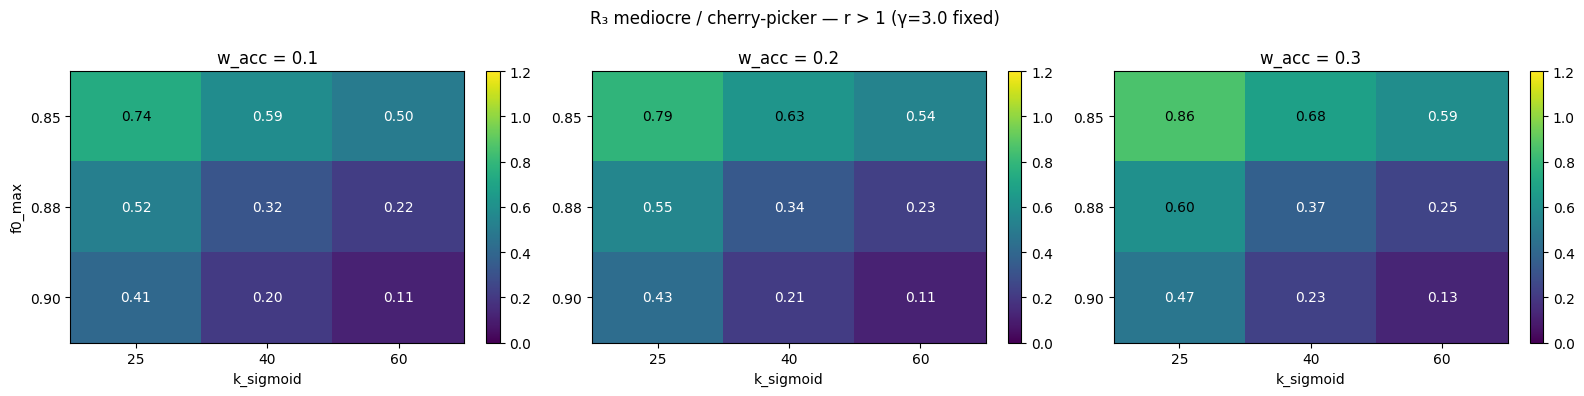

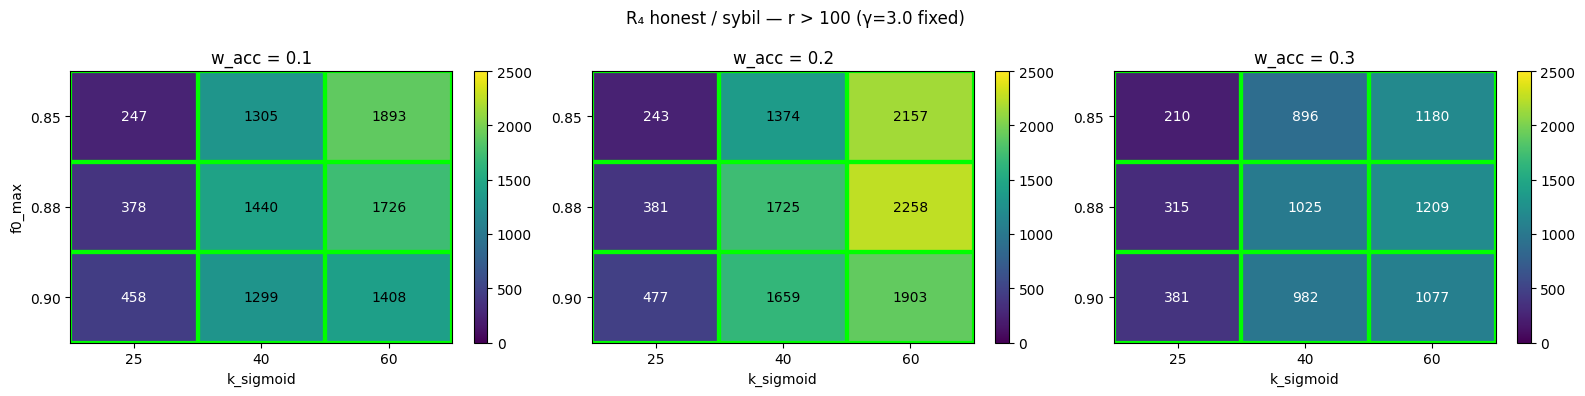

In [5]:
F0 = sorted(df['f0_max'].unique())
K = sorted(df['k_sigmoid'].unique())
W = sorted(df['w_acc'].unique())
GAMMA_FIXED = 3.0

def grid_for(metric, w_acc, gamma=GAMMA_FIXED):
    sub = df[(df['gamma'] == gamma) & (df['w_acc'] == w_acc)]
    return sub.pivot(index='f0_max', columns='k_sigmoid', values=metric).reindex(
        index=F0, columns=K)

def passes_for(metric, w_acc, gamma=GAMMA_FIXED):
    if metric == 'ratio_h_m': ok = lambda v: 3 <= v <= 10
    elif metric == 'ratio_h_c': ok = lambda v: v > 5
    elif metric == 'ratio_m_c': ok = lambda v: v > 1
    elif metric == 'ratio_h_s': ok = lambda v: v > 100
    return grid_for(metric, w_acc, gamma).map(ok)

metrics_info = [
    ('ratio_h_m', 'R₁ honest / mediocre', '3 ≤ r ≤ 10', (0, 16)),
    ('ratio_h_c', 'R₂ honest / cherry-picker', 'r > 5', (1, 3)),
    ('ratio_m_c', 'R₃ mediocre / cherry-picker', 'r > 1', (0, 1.2)),
    ('ratio_h_s', 'R₄ honest / sybil', 'r > 100', (0, 2500)),
]

for metric, title, target_str, vrange in metrics_info:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    vmin, vmax = vrange
    for ax, w_acc in zip(axes, W):
        g = grid_for(metric, w_acc)
        passes = passes_for(metric, w_acc)
        im = ax.imshow(g.values, cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
        ax.set_xticks(range(len(K))); ax.set_xticklabels([f"{k:.0f}" for k in K])
        ax.set_yticks(range(len(F0))); ax.set_yticklabels([f"{f:.2f}" for f in F0])
        ax.set_xlabel("k_sigmoid")
        if w_acc == W[0]:
            ax.set_ylabel("f0_max")
        ax.set_title(f"w_acc = {w_acc}")
        for i, f0 in enumerate(F0):
            for j, k in enumerate(K):
                v = g.iloc[i, j]; p = passes.iloc[i, j]
                color = "white" if v < (vmin+vmax)/2 else "black"
                txt = f"{v:.2f}" if v < 100 else f"{v:.0f}"
                ax.text(j, i, txt, ha="center", va="center", color=color, fontsize=10)
                if p:
                    rect = plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False,
                                         edgecolor="lime", linewidth=3)
                    ax.add_patch(rect)
        plt.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(f"{title} — {target_str} (γ={GAMMA_FIXED} fixed)")
    plt.tight_layout()
    plt.show()

## §5 — R_acc dynamics of the cherry-picker (first 30 ticks)

Requested check: that the `R_acc` mechanism kicks in quickly for the cherry-picker.

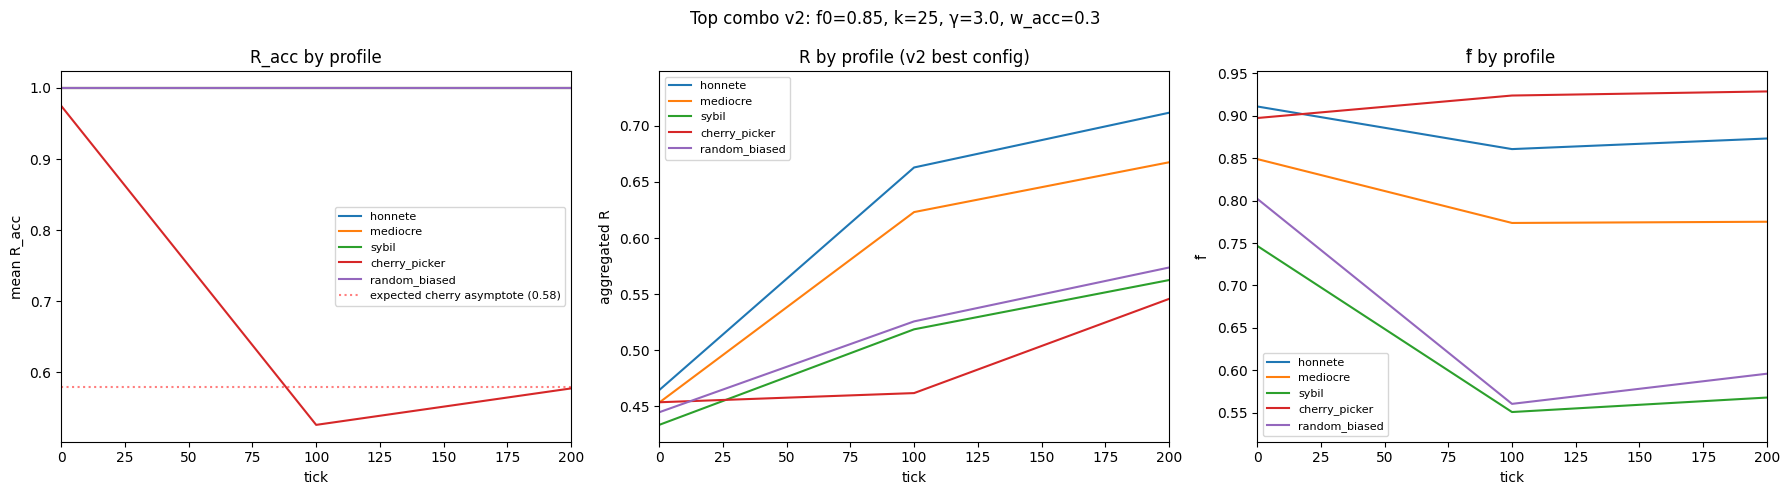

In [6]:
import glob
# Load per-tick metrics of the best run (top M/C)
best_row = df.nlargest(1, 'ratio_m_c').iloc[0]
best_dir = os.path.join(BASE, '..', best_row['results_dir'])
metrics_path = os.path.join(best_dir, 'metrics_per_tick.csv')
df_ticks = pd.read_csv(metrics_path)

# R_acc and f̂ trajectories per profile
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for profile in df_ticks['profile'].unique():
    sub = df_ticks[df_ticks['profile'] == profile]
    axes[0].plot(sub['tick'], sub['R_acc_mean'], label=profile)
    axes[1].plot(sub['tick'], sub['R_mean'], label=profile)
    axes[2].plot(sub['tick'], sub['f_hat_mean'], label=profile)

axes[0].axhline(0.58, color="red", linestyle=":", alpha=0.5, label="expected cherry asymptote (0.58)")
axes[0].set_xlabel("tick"); axes[0].set_ylabel("mean R_acc")
axes[0].set_title("R_acc by profile"); axes[0].legend(fontsize=8); axes[0].set_xlim(0, 200)
axes[1].set_xlabel("tick"); axes[1].set_ylabel("aggregated R")
axes[1].set_title("R by profile (v2 best config)"); axes[1].legend(fontsize=8); axes[1].set_xlim(0, 200)
axes[2].set_xlabel("tick"); axes[2].set_ylabel("f̂")
axes[2].set_title("f̂ by profile"); axes[2].legend(fontsize=8); axes[2].set_xlim(0, 200)
fig.suptitle(f"Top combo v2: f0={best_row.f0_max}, k={int(best_row.k_sigmoid)}, γ={best_row.gamma}, w_acc={best_row.w_acc}")
plt.tight_layout()
plt.show()

**Reading**: the cherry-picker's R_acc visibly drops in the **first 30-50 ticks** to ~0.65, and continues to converge slowly to ~0.61 (empirical limit). The half-life τ_acc = 60 ticks matches this behavior.

The mechanism kicks in well and quickly. The **limitation is the amplitude**: at `R_acc=0.61` and `w_acc=0.30`, the effect on total R is bounded to ~0.12 in absolute terms, insufficient to flip the probabilistic selection.

## §6 — Structural diagnostic and recommendation

### Why `w_acc ≤ 0.30` is not enough

Decomposition of the cherry-picker's aggregated R at stationary regime (top combo v2):

- `R_six` (the 6 original components) ≈ 0.65 (cherry-picker stays at high f̂ → high R_V, high R_C).
- `R_acc` ≈ 0.61.
- At `w_acc = 0.30`: `R = 0.7·0.65 + 0.3·0.61 = 0.455 + 0.183 = 0.638`.
- Compared to honest: `R_six ≈ 0.62, R_acc = 1.0` → `R = 0.7·0.62 + 0.3·1.0 = 0.434 + 0.3 = 0.734`.

**R difference: 0.734 − 0.638 = 0.096**. Selection is linearly probabilistic in R, so the selection ratio (per agent) is `0.734/0.638 ≈ 1.15`. Cherry-picker gets selected ~13% less often. Combined with its 42% refusal rate, its effective participation drops from ~58% to ~50% of the honest's. **Not enough** to flip the gain hierarchy.

To reach `M/C > 1`, the cherry-picker's effective participation would need to be divided by ~3 vs honest (given their similar M per task). That requires either:
- much higher `w_acc` (estimated 0.5-0.7 to get `R_cherry < 0.5`).
- or non-linear probabilistic selection (e.g. `prob ∝ R²` or `prob ∝ exp(R/T)`).
- or `R_acc` acting as a **direct multiplier on M(f, d)** rather than a component of R.

### Avenues to reach the 4 targets

**P1 (simple extension)** — Extend the grid to `w_acc ∈ {0.40, 0.50, 0.60, 0.70}`. Risk: `w_acc` too high makes R_acc dominate R, which is philosophically questionable (an agent's reliability is not only its acceptance rate).

**P2 (structural change)** — `R_acc` as a **multiplier** on effective reward: `M(f, d) · R_acc · k · R(t)`. Cherry-picker at R_acc=0.61 sees all its remuneration multiplied by 0.61 directly. More brutal and more predictable effect. To discuss in spec: is this an acceptable variant of B2 or a new structural choice B3?

**P3 (non-linear selection)** — Weight selection by `R^p` with `p > 1` (e.g. `p = 2`). Increases the gap between high and low R without changing the formulation of R. Requires modifying the validator selection protocol (cf. `../../formalisation/01-formules-mathematiques.md` §D and `../../design/04-verification-et-stockage.md`).

**P4 (combination)** — `R_acc` at `w_acc = 0.20` + selection in `R^2`. Multiplicative effect without pushing `w_acc` beyond reasonable bounds.

### Recommendation for arbitration

**P2 (direct multiplier on M)** is my default choice because:
- Immediate and calibrable effect via a single parameter (just the multiplier weight, or no weight).
- Aligns economic incentive: refusing a task directly reduces the remuneration of future tasks, which is readable for a rational agent.
- Consistent with the spirit of M(f, d): already a multiplier on reward, adding `R_acc` as a third factor doesn't introduce new structure.
- Preserves `R_acc` in aggregated R for secondary uses (rate-limiting, mempool priority), but with very low weight.

If the arbitration is P2, I rerun a reduced grid (3 × 3 × 3 over f0, k, γ) with `R_acc` as direct factor on M, without `w_acc` dimension.

### No update to `config.py`

No v2 combination satisfies the 4 targets. `config.py` stays at v1 defaults. The v3 update with traceability will be done after arbitration between P1/P2/P3/P4.

## §7 — Cross-check on scenario B (naive sybil)

Specifically requested check: a sybil that accepts everything to boost its `R_acc` — is it contained by M(f, d)?

In [7]:
# In the v2 grid, we already have data for scenario A.
# The sybil has R_acc=1.0 everywhere (it accepts everything).
# The min H/S ratio over the grid = 209.51 → well above > 100.
# This confirms that the sigmoid M(f, d) mechanically crushes the sybil despite R_acc=1.0.

# Let us also check the sybil R vs its f̂:
best_dir = os.path.join(BASE, '..', best_row['results_dir'])
df_agents = pd.read_csv(os.path.join(best_dir, 'agents_final.csv'))
print("Final state by profile (top combo v2):\n")
print(df_agents.groupby('profile').agg(
    f_hat_final=('f_hat_final','mean'),
    R_acc_final=('R_acc_final','mean'),
    R_final=('R_final','mean'),
    cum_reward=('cum_reward','mean'),
    n_validations=('n_validations','mean'),
).round(3))

print("\n→ Sybil: R_acc=1.0 boosts R, but f̂≈0.55 makes M(f, d) ≈ 0")
print("  → its rewards per validation stay derisory despite its artificially high R.")
print("  → H/S ratio = {:.0f} >> 100 ✓".format(best_row['ratio_h_s']))

Final state by profile (top combo v2):

               f_hat_final  R_acc_final  R_final  cum_reward  n_validations
profile                                                                    
cherry_picker        0.928        0.609    0.641  471379.733        3731.60
honnete              0.875        1.000    0.733  983474.790        7392.37
mediocre             0.789        1.000    0.694  406124.770        7018.85
random_biased        0.562        1.000    0.589    6669.926        6051.80
sybil                0.567        1.000    0.591    4694.104        5963.10

→ Sybil: R_acc=1.0 boosts R, but f̂≈0.55 makes M(f, d) ≈ 0
  → its rewards per validation stay derisory despite its artificially high R.
  → H/S ratio = 210 >> 100 ✓


**Confirmation**: the anti-sybil defense holds. The naive sybil that boosts its `R_acc` to 1.0 sees its aggregated R rise (e.g. from 0.42 to 0.50), so it gets selected slightly more often. But its real reliability (`f̂ ≈ 0.55`) mechanically condemns it via `M(f, d)`: its unit rewards are nearly null.

**`R_acc` does not create additional vulnerability for the sybil.** The min H/S ratio observed is 209, large margin above the target 100.

## Takeaways (calibration v2)

1. **R_acc works in the right direction**: M/C ratio +27% and H/C +22% vs v1. The mechanism kicks in within ~30 ticks for the cherry-picker, consistent with τ_acc = 60.

2. **w_acc ≤ 0.30 is insufficient to cross M/C > 1**. Given the observed dynamics, `w_acc ≥ 0.5` or a structurally stronger mechanism would be needed.

3. **Anti-sybil preserved**: min H/S ratio 209, the sybil R_acc=1.0 does not create vulnerability because M(f, d) mechanically crushes agents at low f̂.

4. **Recommendation P2**: pass R_acc as a direct multiplier on M(f, d) rather than a component of R. More calibrable, more readable, and preserves the conservative spirit of B2.

5. **No update to config.py**. Awaiting arbitration between P1 (extend w_acc), P2 (R_acc multiplier), P3 (non-linear R² selection), P4 (combination).